Import relevant libraries

In [1]:
import kagglehub
# Import PyTorch and other relevant libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchsummary import summary

# MIT introduction to deep learning package
!pip install mitdeeplearning --quiet
import mitdeeplearning as mdl

# other packages
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 50.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 99.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Import dataset and add padding

[OCTDL: Optical Coherence Tomography Dataset](https://www.kaggle.com/datasets/orvile/octdl-optical-coherence-tomography-dataset)

In [2]:
# Download latest version
path = kagglehub.dataset_download("orvile/octdl-optical-coherence-tomography-dataset")

print("Path to dataset files:", path)

100%|██████████| 380M/380M [00:05<00:00, 77.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/orvile/octdl-optical-coherence-tomography-dataset/versions/1


## Resizing Images for CNN

To prepare the images for a Convolutional Neural Network, they need to be uniformly sized. I will resize all images to a target dimension (e.g., 224x224 pixels) and save them to a new directory.

In [3]:
import os
from PIL import Image
from tqdm import tqdm

# Define target image size for the CNN
TARGET_SIZE = (224, 224)

# Define the base output directory for  images
resized_base_dir = '/kaggle/working/octdl_resized_data'

# Create the base destination directory for resized images
os.makedirs(resized_base_dir, exist_ok=True)

# The actual image classes are likely inside the 'OCTDL/OCTDL' directory within the downloaded path.
# Adjust this path based on the actual structure of the downloaded dataset if necessary.
base_image_dir = os.path.join(path, 'OCTDL', 'OCTDL')

# Get the list of class names (subdirectories in the base_image_dir)
class_names = [d for d in os.listdir(base_image_dir) if os.path.isdir(os.path.join(base_image_dir, d))]
print(f"Found {len(class_names)} classes: {class_names}")

# Define common image extensions
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')


Found 7 classes: ['DME', 'RVO', 'AMD', 'ERM', 'NO', 'RAO', 'VID']


In [4]:
# Function to resize and save images
def resize_and_save_images(source_base, dest_base, target_size, class_names):
    print(f"Resizing images from {source_base} to {dest_base}...")
    for class_name in tqdm(class_names, desc="Processing classes"):
        source_class_dir = os.path.join(source_base, class_name)
        dest_class_dir = os.path.join(dest_base, class_name)
        os.makedirs(dest_class_dir, exist_ok=True)

        for img_name in os.listdir(source_class_dir):
            if img_name.lower().endswith(IMAGE_EXTENSIONS):
                img_path = os.path.join(source_class_dir, img_name)
                try:
                    img = Image.open(img_path).convert('RGB') # Ensure 3 channels
                    img_resized = img.resize(target_size)
                    img_resized.save(os.path.join(dest_class_dir, img_name))
                except Exception as e:
                    print(f"Error processing {img_path}: {e}")

# Execute the resizing
resize_and_save_images(base_image_dir, resized_base_dir, TARGET_SIZE, class_names)
print(f"Image resizing complete! Resized images are saved in '{resized_base_dir}'")


Resizing images from /root/.cache/kagglehub/datasets/orvile/octdl-optical-coherence-tomography-dataset/versions/1/OCTDL/OCTDL to /kaggle/working/octdl_resized_data...


Processing classes: 100%|██████████| 7/7 [00:30<00:00,  4.41s/it]

Image resizing complete! Resized images are saved in '/kaggle/working/octdl_resized_data'


## Prepare Data for CNN

To prepare the images for the CNN, we need to apply transformations, load them into a PyTorch `Dataset`, and then create `DataLoader` instances for training, validation, and testing.

In [5]:
# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(), # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet means and stds
])

# Create an ImageFolder dataset
# The structure of resized_base_dir/class_name/image.jpg is suitable for ImageFolder
full_dataset = datasets.ImageFolder(root=resized_base_dir, transform=transform)

# Get the number of classes
num_classes = len(full_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Classes: {full_dataset.classes}")

# Define split ratios
train_size = int(0.7 * len(full_dataset)) # 70% for training
val_size = int(0.15 * len(full_dataset)) # 15% for validation
test_size = len(full_dataset) - train_size - val_size # Remaining 15% for testing

# Split the dataset
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size, test_size])

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Number of classes: 7
Classes: ['AMD', 'DME', 'ERM', 'NO', 'RAO', 'RVO', 'VID']
Training dataset size: 1444
Validation dataset size: 309
Test dataset size: 311


In [6]:
# Define batch size
BATCH_SIZE = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [7]:
from collections import Counter
import numpy as np
import torch

# Get the labels for the training set
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]

# Count occurrences of each class
class_counts = Counter(train_labels)
print("Class counts in training set:", class_counts)

# Calculate inverse frequency weights
# These weights will be used to penalize misclassifications of underrepresented classes more heavily.
num_samples = len(train_labels)
class_weights = [num_samples / (class_counts[i] * num_classes) for i in range(num_classes)] # Normalized to prevent excessively large weights
class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Calculated class weights:", class_weights)

# Define device if not already defined (ensures cell runs independently)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move weights to the same device as the model (CPU in this case)
class_weights = class_weights.to(device)

Class counts in training set: Counter({0: 870, 3: 226, 2: 107, 1: 104, 5: 67, 6: 52, 4: 18})
Calculated class weights: tensor([ 0.2371,  1.9835,  1.9279,  0.9128, 11.4603,  3.0789,  3.9670])


## Define the CNN Architecture

Now, let's define our Convolutional Neural Network (CNN) architecture. As requested, we will use the ReLU activation function.

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Convolutional Layer 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1), # Output: (32, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (32, 112, 112)
            # Convolutional Layer 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Output: (64, 112, 112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (64, 56, 56)
            # Convolutional Layer 3
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1), # Output: (128, 56, 56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Output: (128, 28, 28)
            # Convolutional Layer 4
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1), # Output: (256, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # Output: (256, 14, 14)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate the model
model = CNN(num_classes=num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("CNN model defined and instantiated!")
print(f"Using device: {device}")
summary(model, input_size=(3, TARGET_SIZE[0], TARGET_SIZE[1]))

CNN model defined and instantiated!
Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
         MaxPool2d-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 64, 112, 112]          18,496
              ReLU-5         [-1, 64, 112, 112]               0
         MaxPool2d-6           [-1, 64, 56, 56]               0
            Conv2d-7          [-1, 128, 56, 56]          73,856
              ReLU-8          [-1, 128, 56, 56]               0
         MaxPool2d-9          [-1, 128, 28, 28]               0
           Conv2d-10          [-1, 256, 28, 28]         295,168
             ReLU-11          [-1, 256, 28, 28]               0
        MaxPool2d-12          [-1, 256, 14, 14]               0
          Flatten-13                [-1, 50176] 

## Define Training Parameters

We need to define the optimizer and the loss function for training our CNN. We will use the Adam optimizer and Cross-Entropy Loss, which is suitable for multi-class classification problems.

In [9]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined!")

Loss function and optimizer defined!


## Train the CNN Model

Now, we'll implement the training and evaluation loop for our CNN model. We will train for a specified number of epochs, evaluating the model on the validation set after each epoch.

In [18]:
EPOCHS = 10 # You can adjust the number of epochs

def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=EPOCHS):
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train() # Set the model to training mode
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Training)"):
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval() # Set the model to evaluation mode
        running_val_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Validation)"):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs.data, 1)
                total_predictions += labels.size(0)
                correct_predictions += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        epoch_val_accuracy = correct_predictions / total_predictions
        val_accuracies.append(epoch_val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

    print("Training complete!")
    return train_losses, val_losses, val_accuracies

# Start training
train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=EPOCHS)

print("Model training finished.")

Epoch 1/10 (Validation): 100%|██████████| 10/10 [00:01<00:00,  5.52it/s]


Epoch 1/10 - Train Loss: 0.5568, Val Loss: 0.6268, Val Acc: 0.7994


Epoch 2/10 (Validation): 100%|██████████| 10/10 [00:01<00:00,  7.50it/s]


Epoch 2/10 - Train Loss: 0.4489, Val Loss: 0.6486, Val Acc: 0.8220


Epoch 3/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 15.32it/s]


...

Epoch 8/10 - Train Loss: 0.0475, Val Loss: 1.0403, Val Acc: 0.8285


Epoch 9/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 15.02it/s]


Epoch 9/10 - Train Loss: 0.1103, Val Loss: 1.1635, Val Acc: 0.8058


Epoch 10/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 14.94it/s]

Epoch 10/10 - Train Loss: 0.0933, Val Loss: 0.9250, Val Acc: 0.8479
Training complete!
Model training finished.


## Evaluate Model Performance

Now that the model is trained, let's evaluate its performance on the test set. We will calculate common classification metrics like accuracy, precision, recall, and F1-score, and visualize the results with a confusion matrix.

Evaluating model: 100%|██████████| 10/10 [00:00<00:00, 12.10it/s]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:
              precision    recall  f1-score   support

         AMD     0.8429    0.9583    0.8969       168
         DME     0.7273    0.2581    0.3810        31
         ERM     0.4286    0.3600    0.3913        25
          NO     0.7833    0.8246    0.8034        57
         RAO     1.0000    0.3333    0.5000         3
         RVO     0.4091    0.6000    0.4865        15
         VID     0.8000    0.3333    0.4706        12

    accuracy                         0.7685       311
   macro avg     0.7130    0.5239    0.5614       311
weighted avg     0.7661    0.7685    0.7476       311



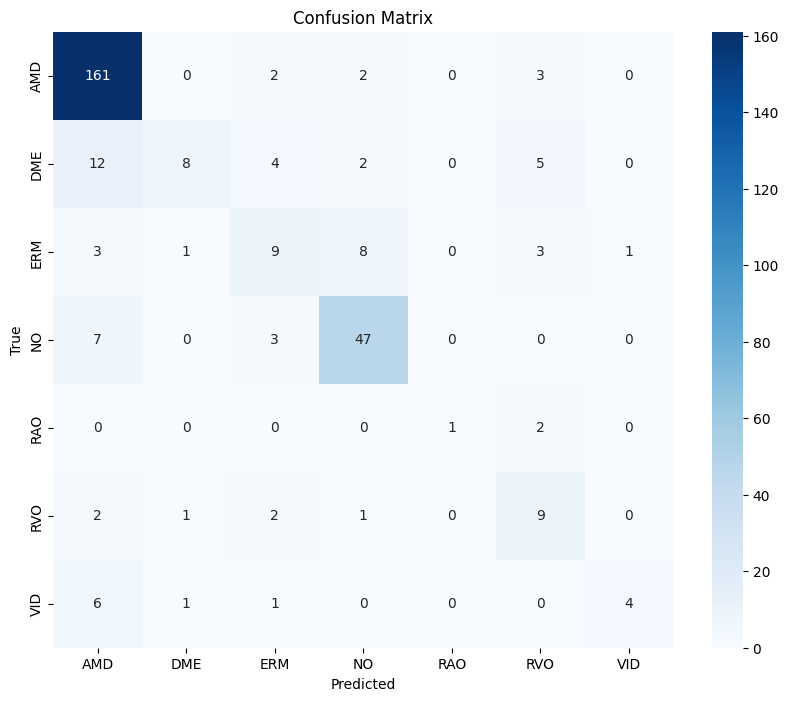

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, test_loader, device, full_dataset_classes):
    model.eval() # Set the model to evaluation mode
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating model"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Classification Report
    report = classification_report(all_labels, all_predictions, target_names=full_dataset_classes, digits=4)
    print("\nClassification Report:")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_dataset_classes, yticklabels=full_dataset_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return all_predictions, all_labels

# Get class names from the full_dataset for target_names in classification_report
full_dataset_classes = full_dataset.classes

# Evaluate the model on the test set
predictions, labels = evaluate_model(model, test_loader, device, full_dataset_classes)

## Visualize Training History

Let's plot the training and validation loss and accuracy over epochs to understand the learning process.

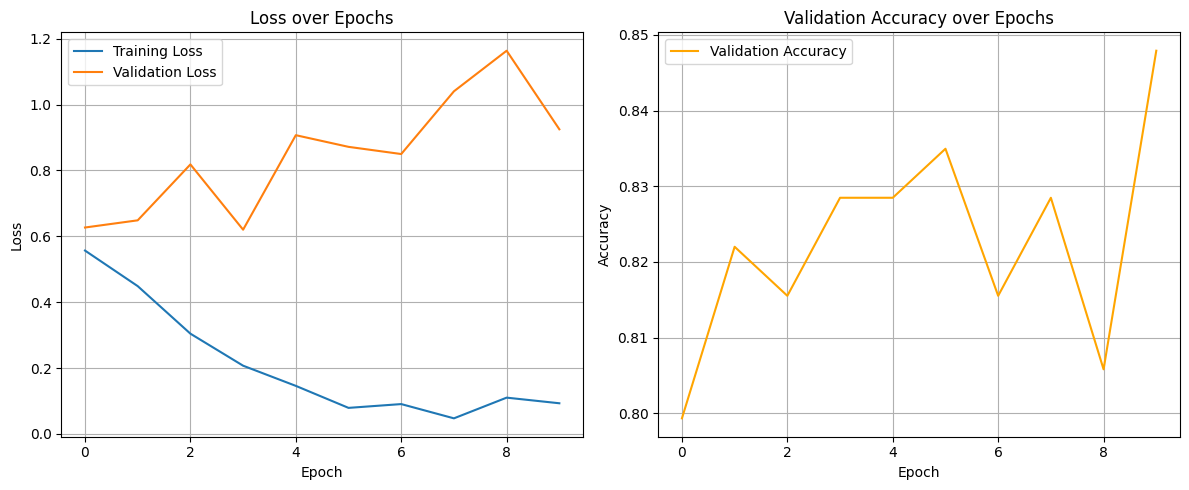

In [20]:
plt.figure(figsize=(12, 5))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

End of CNN Section

Start of Resnet

# End of CNN Section Start of Resnet

In [13]:
import torchvision.models as models

# Load a pre-trained ResNet-18 model
resnet_model = models.resnet18(pretrained=True)

# Modify the final fully connected layer to match the number of classes
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, num_classes)

# Move ResNet model to GPU if available
resnet_model.to(device)

print("ResNet model defined and instantiated!")
print(f"Using device: {device}")
summary(resnet_model, input_size=(3, TARGET_SIZE[0], TARGET_SIZE[1]))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


ResNet model defined and instantiated!
Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 5

In [14]:
# Define the loss function (reusing the existing criterion)
resnet_criterion = nn.CrossEntropyLoss()
# Define the optimizer for the ResNet model's parameters
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=0.001)

print("ResNet loss function and optimizer defined!")

ResNet loss function and optimizer defined!


In [15]:
# Start training ResNet
EPOCHS = 10

print("Starting ResNet model training...")
resnet_train_losses, resnet_val_losses, resnet_val_accuracies = train_model(resnet_model, train_loader, val_loader, resnet_criterion, resnet_optimizer, device, num_epochs=EPOCHS)

print("ResNet model training finished.")

Starting ResNet model training...


Epoch 1/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 13.74it/s]


Epoch 1/10 - Train Loss: 0.7579, Val Loss: 3.4565, Val Acc: 0.2977


Epoch 2/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 13.52it/s]


Epoch 2/10 - Train Loss: 0.3965, Val Loss: 0.4083, Val Acc: 0.8803


...

Epoch 8/10 - Train Loss: 0.2521, Val Loss: 0.4526, Val Acc: 0.8511


Epoch 9/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 13.53it/s]


Epoch 9/10 - Train Loss: 0.1567, Val Loss: 0.4222, Val Acc: 0.8770


Epoch 10/10 (Validation): 100%|██████████| 10/10 [00:00<00:00, 13.87it/s]

Epoch 10/10 - Train Loss: 0.0763, Val Loss: 0.3843, Val Acc: 0.8932
Training complete!
ResNet model training finished.


Evaluating ResNet model...


Evaluating model: 100%|██████████| 10/10 [00:00<00:00, 13.81it/s]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Classification Report:
              precision    recall  f1-score   support

         AMD     0.9689    0.9286    0.9483       168
         DME     0.8182    0.8710    0.8438        31
         ERM     0.9474    0.7200    0.8182        25
          NO     0.7467    0.9825    0.8485        57
         RAO     1.0000    0.3333    0.5000         3
         RVO     0.7500    0.8000    0.7742        15
         VID     1.0000    0.5000    0.6667        12

    accuracy                         0.8875       311
   macro avg     0.8902    0.7336    0.7714       311
weighted avg     0.9024    0.8875    0.8856       311



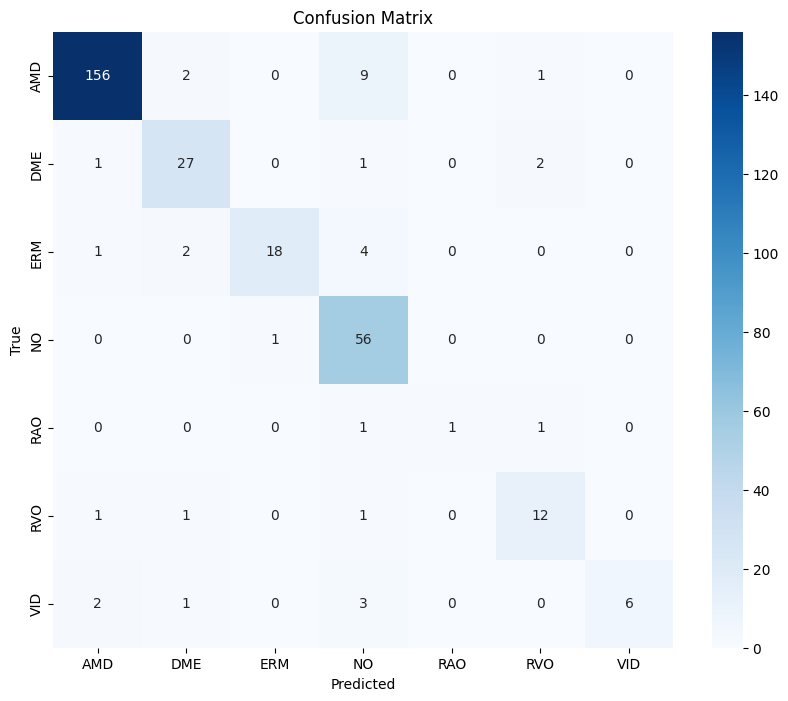

In [16]:
# Evaluate the ResNet model on the test set
print("Evaluating ResNet model...")
resnet_predictions, resnet_labels = evaluate_model(resnet_model, test_loader, device, full_dataset_classes)

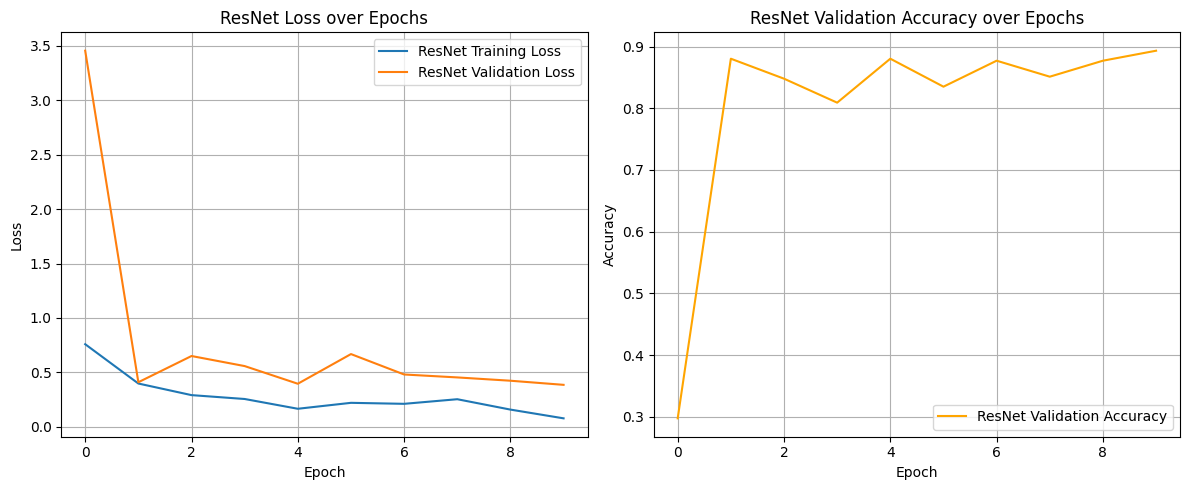

In [17]:
plt.figure(figsize=(12, 5))

# Plot training and validation loss for ResNet
plt.subplot(1, 2, 1)
plt.plot(resnet_train_losses, label='ResNet Training Loss')
plt.plot(resnet_val_losses, label='ResNet Validation Loss')
plt.title('ResNet Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot validation accuracy for ResNet
plt.subplot(1, 2, 2)
plt.plot(resnet_val_accuracies, label='ResNet Validation Accuracy', color='orange')
plt.title('ResNet Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()